# step-1: load necessary libs and load the article-review data into a dataframe

In [3]:
# Import necessary libraries
import pandas as pd
import xlrd  # Ensure xlrd is installed for .xls file support

# Load the Excel file into a dataframe
file_path = "../article-review-export-for-python.xls"
df = pd.read_excel(file_path, engine='xlrd')


# country distribution

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np

# Load the Excel file into a dataframe
file_path = "../article-review-export-for-python.xls"
df = pd.read_excel(file_path, engine='xlrd')

# Group the articles by country
country_counts = df['Author Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Article Count']

# Apply logarithmic transformation to the article counts for better visualization
country_counts['Log Article Count'] = np.log1p(country_counts['Article Count'])

# Generate coolwarm color palette from matplotlib for continuous scale
coolwarm_colors = plt.cm.coolwarm(np.linspace(0, 1, 256))
coolwarm_palette = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in coolwarm_colors]

# Create a choropleth map to display the distribution of articles by country
fig = px.choropleth(country_counts,
                    locations="Country",
                    locationmode="country names",
                    color="Log Article Count",
                    hover_name="Country",
                    hover_data={"Country": True, "Article Count": True},  # Use actual scale in hover label
                    color_continuous_scale=coolwarm_palette,  # Apply coolwarm palette
                    title="Distribution of Articles by Country (Log Scale)")

# Update layout to double the size and set non-contributing countries' background to white
fig.update_layout(
    width=1400,  # Double the default width
    height=800,  # Double the default height
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='natural earth',
        bgcolor='white'  # Set non-contributing countries' background to white
    ),
    showlegend=False  # Remove the right legend completely
)

# Show the map
fig.show()


In [5]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Load the Excel file into a dataframe
file_path = "../article-review-export-for-python.xls"
df = pd.read_excel(file_path, engine='xlrd')

# Generate coolwarm color palette from matplotlib for the number of categories
num_categories = df['Main Category'].nunique()
coolwarm_colors = plt.cm.coolwarm(np.linspace(0, 1, num_categories))

# Convert the colors to hex format for Plotly
coolwarm_palette = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in coolwarm_colors]

# Publication Volume Growth Analysis
# Group the publications by year and main category
df_grouped = df.groupby(['year', 'Main Category']).size().reset_index(name='Count')

# Create a stacked bar chart to display the volume growth of publications over time using the exact coolwarm palette
fig = px.bar(df_grouped, 
             x='year', 
             y='Count', 
             color='Main Category',
             barmode='stack',
             title='Publication Category Volume Growth Over Time',
             labels={'year': 'Year', 'Count': 'Number of Publications', 'Main Category': 'Main Category'},
             color_discrete_sequence=coolwarm_palette  # Apply exact matplotlib coolwarm palette
)

# Calculate cumulative growth in publication volume over time
cumulative_publication_growth = df_grouped.groupby('year')['Count'].sum().cumsum()

# Add a line representing the cumulative growth in publications over time with secondary y-axis
fig.add_trace(go.Scatter(
    x=cumulative_publication_growth.index,
    y=cumulative_publication_growth,
    mode='lines+markers',
    name='Cumulative Growth',
    line=dict(color='black', dash='dash', shape='spline'),
    yaxis='y2'
))

# Update layout for better readability and add secondary y-axis for cumulative growth
fig.update_layout(
    width=1120,  # Reduce the width by 20%
    height=640,  # Reduce the height by 20%
    xaxis_title='Year',
    yaxis_title='Number of Publications',
    xaxis=dict(tickmode='linear', dtick=1),  # Ensure only years are shown on x-axis
    margin=dict(l=100, r=150, t=100, b=100),  # Set a margin around the chart area, increase right margin
    yaxis2=dict(
        title='Cumulative Growth in Publications',
        overlaying='y',
        side='right',
        showgrid=False,
        tickformat='.0f'  # Use integer format for cumulative growth
    ),
    legend=dict(
        x=1.1,  # Move legend further to the right to avoid overlap
        y=1,
        traceorder='normal'
    )
)

# Show the stacked bar chart with the cumulative growth line
fig.show()

# Average increase in publication volume over the years
average_publication_increase = cumulative_publication_growth.pct_change().mean() * 100

# Top 3 categories based on total publications
top_3_categories = df_grouped.groupby('Main Category')['Count'].sum().sort_values(ascending=False).head(3)

# Summary metrics
print("Cumulative Growth in Publications Over Time:")
print(cumulative_publication_growth)
print("\nAverage Yearly Increase in Publication Volume: {:.2f}%".format(average_publication_increase))
print("\nTop 3 Categories Based on Total Publications:")
print(top_3_categories)

# Calculate additional metrics for trends
# Yearly average number of publications
yearly_avg_publications = df_grouped.groupby('year')['Count'].mean()
print("\nYearly Average Number of Publications:")
print(yearly_avg_publications)

# Total number of unique categories
total_unique_categories = df_grouped['Main Category'].nunique()
print("\nTotal Number of Unique Categories:", total_unique_categories)


Cumulative Growth in Publications Over Time:
year
2020     1
2021     6
2022    13
2023    27
2024    57
Name: Count, dtype: int64

Average Yearly Increase in Publication Volume: 208.87%

Top 3 Categories Based on Total Publications:
Main Category
HR & Talent                14
Business Transformation    13
Decision Making             6
Name: Count, dtype: int64

Yearly Average Number of Publications:
year
2020    1.000000
2021    1.250000
2022    1.166667
2023    2.000000
2024    4.285714
Name: Count, dtype: float64

Total Number of Unique Categories: 10


In [4]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from collections import Counter
import pandas as pd

# Generate coolwarm color palette from matplotlib
num_colors = 10  # Number of colors (for the top 10 keywords)
coolwarm_colors = plt.cm.coolwarm(np.linspace(0, 1, num_colors))

# Convert the colors to hex format for Plotly
coolwarm_palette = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in coolwarm_colors]

# Create a grouped bar chart to display keyword trends over time using the exact coolwarm palette
fig = px.bar(keyword_trends_df, 
             x='Year', 
             y='Count', 
             color='Keyword',
             barmode='group',
             title='Keyword Trends Over Time for Top 10 Keywords',
             labels={'Year': 'Year', 'Count': 'Number of Occurrences', 'Keyword': 'Keyword'},
             color_discrete_sequence=coolwarm_palette  # Apply exact matplotlib coolwarm palette
)

# Calculate trend metrics
# Overall increase in keyword occurrences
overall_increase = keyword_trends_df.groupby('Year')['Count'].sum().pct_change().fillna(0) * 100

# Add a line representing the overall percentage increase in keywords per year with secondary y-axis
fig.add_trace(go.Scatter(
    x=overall_increase.index,
    y=overall_increase,
    mode='lines+markers',
    name='Overall Percentage Increase',
    line=dict(color='black', dash='dash', shape='spline'),
    yaxis='y2'
))

# Update layout for better readability and add secondary y-axis for percentage increase
fig.update_layout(
    width=1120,  # Reduce the width by 20%
    height=640,  # Reduce the height by 20%
    xaxis_title='Year',
    yaxis_title='Number of Occurrences',
    xaxis=dict(tickmode='linear', dtick=1),  # Ensure only full years are shown on x-axis
    margin=dict(l=100, r=150, t=100, b=100),  # Set a margin around the chart area, increase right margin
    yaxis2=dict(
        title='Overall Percentage Increase (%)',
        overlaying='y',
        side='right',
        showgrid=False,
        tickformat='.0f'  # Use integer format for percentage increase
    ),
    legend=dict(
        x=1.1,  # Move legend further to the right to avoid overlap
        y=1,
        traceorder='normal'
    )
)

# Show the grouped bar chart with the additional line
fig.show()


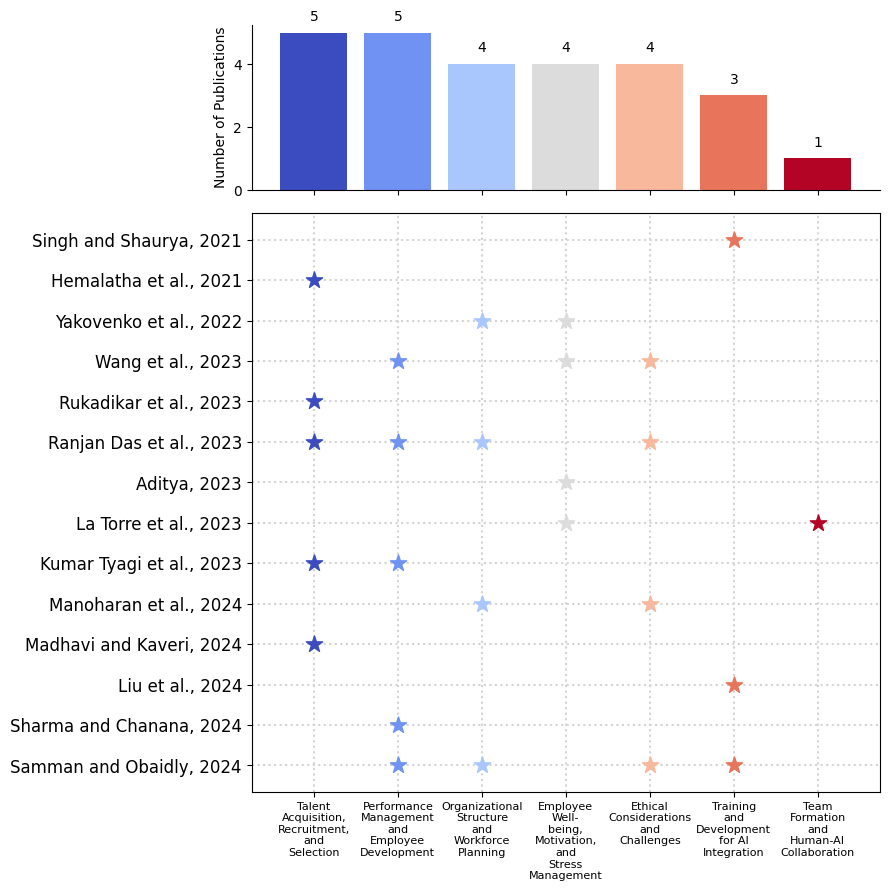

In [38]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# Data provided
subsections = [
    'Talent Acquisition, Recruitment, and Selection',
    'Organizational Structure and Workforce Planning',
    'Team Formation and Human-AI Collaboration',
    'Performance Management and Employee Development',
    'Employee Well-being, Motivation, and Stress Management',
    'Ethical Considerations and Challenges',
    'Training and Development for AI Integration'
]
publications = [
    ['A37', 'A42', 'A54', 'A56', 'A7'],
    ['A26', 'A68', 'A54', 'A71'],
    ['A49'],
    ['A39', 'A54', 'A56', 'A71', 'A78'],
    ['A13', 'A26', 'A49', 'A78'],
    ['A54', 'A68', 'A71', 'A78'],
    ['A80', 'A79', 'A71']
]

# Replace publication index keys with author and year, and sort by publication year descending
publication_mapping = {
    'A13': 'Aditya, 2023',
    'A26': 'Yakovenko et al., 2022',
    'A37': 'Rukadikar et al., 2023',
    'A39': 'Sharma and Chanana, 2024',
    'A42': 'Hemalatha et al., 2021',
    'A49': 'La Torre et al., 2023',
    'A54': 'Ranjan Das et al., 2023',
    'A56': 'Kumar Tyagi et al., 2023',
    'A68': 'Manoharan et al., 2024',
    'A71': 'Samman and Obaidly, 2024',
    'A78': 'Wang et al., 2023',
    'A79': 'Singh and Shaurya, 2021',
    'A7': 'Madhavi and Kaveri, 2024',
    'A80': 'Liu et al., 2024'
}

# Update publications with new labels
publications = [[publication_mapping[pub] for pub in pub_list] for pub_list in publications]

# Extract unique publications and sort by year descending
unique_publications = sorted(set(pub for pub_list in publications for pub in pub_list), key=lambda x: int(x.split(', ')[-1]), reverse=True)

# Sort subsections and publications by the number of publications descending
subsections_publications = sorted(zip(subsections, publications), key=lambda x: len(x[1]), reverse=True)
subsections, publications = zip(*subsections_publications)

# Wrap subsection labels for better readability without splitting words
wrapped_subsections = [textwrap.fill(label, width=8, break_long_words=False) for label in subsections]  # Reduce width for more wrapping

# Create the figure and axes
fig, (ax_hist, ax_scatter) = plt.subplots(nrows=2, ncols=1, sharex=True, gridspec_kw={'height_ratios': [2, 7]}, figsize=(9, 9))  # 25% smaller

# Create the histogram
column_sums = [len(pub_list) for pub_list in publications]
x_ticks = np.arange(len(subsections)) + 5
y_ticks = np.arange(len(unique_publications))
color_palette = plt.cm.coolwarm(np.linspace(0, 1, len(subsections)))

bars = ax_hist.bar(x_ticks, column_sums, color=color_palette)

# Add the sums inside the bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax_hist.text(bar.get_x() + bar.get_width() / 2, height + 0.5, str(int(height)), ha='center', va='center', color='black')

# Set labels and title for the histogram
ax_hist.set_ylabel('Number of Publications')

# Create the scatter plot
for i, publication in enumerate(unique_publications):
    y = i + 1
    for j, pub_list in enumerate(publications):
        x = j + 5
        if publication in pub_list:
            ax_scatter.scatter(x, y, marker='*', s=150, color=color_palette[j])

# Set x-axis ticks and labels for the scatter plot
ax_scatter.set_xticks(x_ticks)
ax_scatter.set_xticklabels(wrapped_subsections, fontsize=8, ha='center')

# Set y-axis ticks and labels for the scatter plot
ax_scatter.set_yticks(np.arange(1, len(unique_publications) + 1))
ax_scatter.set_yticklabels(unique_publications, fontsize=12)

# Remove top and right spines for cleaner look
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)

# Add vertical grid lines
for x in x_ticks:
    ax_scatter.axvline(x, color='lightgray', linestyle='dotted', zorder=-1)

# Add horizontal dashed grid lines
for y in range(1, len(unique_publications) + 1):
    ax_scatter.axhline(y, color='lightgray', linestyle='dotted', zorder=-1)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()